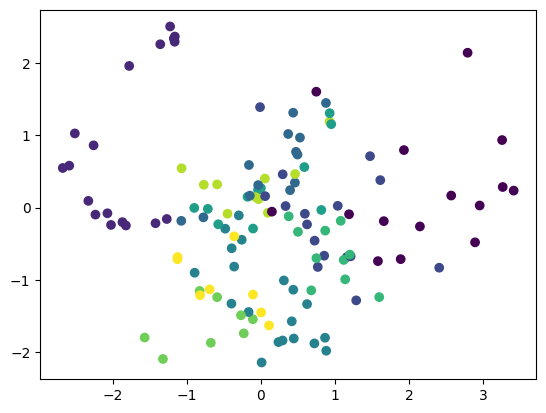

In [4]:
!pip install torch torchvision matplotlib

import torch, torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# data
loader = torch.utils.data.DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transforms.ToTensor()),
    batch_size=128, shuffle=True)

# model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.mu = nn.Linear(128, 2)
        self.logvar = nn.Linear(128, 2)
        self.fc2 = nn.Linear(2, 128)
        self.fc3 = nn.Linear(128, 784)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        mu, logvar = self.mu(h), self.logvar(h)
        std = torch.exp(0.5*logvar)
        z = mu + std * torch.randn_like(std)
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h)), mu, logvar

model = VAE().to(device)
opt = torch.optim.Adam(model.parameters(), 1e-3)

# train (VERY SHORT)
for _ in range(3):
    for x,_ in loader:
        x = x.view(-1,784).to(device)
        recon, mu, logvar = model(x)
        loss = ((recon-x)**2).sum() - 0.5*torch.sum(1+logvar-mu**2-logvar.exp())
        opt.zero_grad(); loss.backward(); opt.step()

# visualize latent
x,y = next(iter(loader))
with torch.no_grad():
    mu,_ = model(x.view(-1,784).to(device))[1:]

z = mu.cpu()
plt.scatter(z[:,0], z[:,1], c=y)
plt.show()

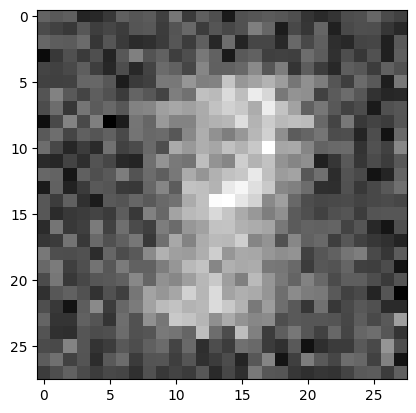

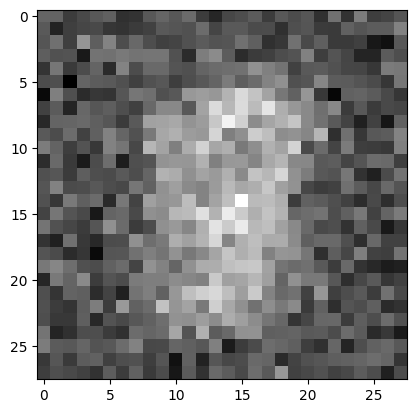

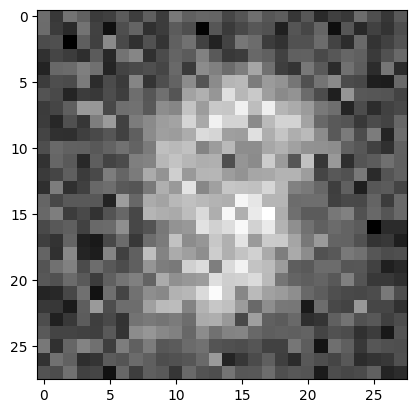

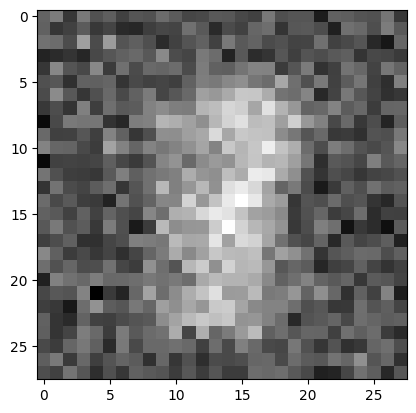

In [5]:
import torch.nn as nn

G = nn.Sequential(nn.Linear(100,128), nn.ReLU(), nn.Linear(128,784), nn.Tanh()).to(device)
D = nn.Sequential(nn.Linear(784,128), nn.ReLU(), nn.Linear(128,1), nn.Sigmoid()).to(device)

optG = torch.optim.Adam(G.parameters(), 0.0002)
optD = torch.optim.Adam(D.parameters(), 0.0002)
loss_fn = nn.BCELoss()

for _ in range(3):
    for x,_ in loader:
        x = x.view(-1,784).to(device)

        z = torch.randn(x.size(0),100).to(device)
        fake = G(z)

        # D
        lossD = loss_fn(D(x), torch.ones_like(D(x))) + \
                loss_fn(D(fake.detach()), torch.zeros_like(D(fake)))
        optD.zero_grad(); lossD.backward(); optD.step()

        # G
        lossG = loss_fn(D(fake), torch.ones_like(D(fake)))
        optG.zero_grad(); lossG.backward(); optG.step()

# generate
z = torch.randn(4,100).to(device)
imgs = G(z).view(-1,28,28).detach().cpu()

for i in range(4):
    plt.imshow(imgs[i], cmap='gray'); plt.show()

In [6]:
!pip install torch-geometric

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

data = Planetoid(root='/tmp/Cora', name='Cora')[0]

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = GCNConv(data.num_node_features, 16)
        self.c2 = GCNConv(16, data.y.max().item()+1)

    def forward(self, x, edge_index):
        x = self.c1(x, edge_index).relu()
        x = self.c2(x, edge_index)
        return x

model = GCN()
opt = torch.optim.Adam(model.parameters(), lr=0.01)

for _ in range(20):
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    opt.zero_grad(); loss.backward(); opt.step()

pred = model(data.x, data.edge_index).argmax(dim=1)
acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
print("Accuracy:", acc.item())

Accuracy: 0.7870000004768372
